# Model Fitting for SIRSEI Malaria Model

This notebook demonstrates fitting the SIRSEI (Susceptible-Infectious-Recovered for Humans, Susceptible-Exposed-Infectious for Mosquitoes) malaria model to real epidemiological data from Manaus.

## Overview

The fitting process uses:
- **Real climate data**: Temperature and precipitation from `climate_api_data_2016_2024.csv`
- **Real case data**: Active malaria cases from `cumulative_manaus_cases_2016_2023.csv`
- **State variable**: `active_total` as a proxy for `Ih` (Infectious Humans)

## Parameters

### Optimizable Parameters:
- `T_prime`: Base temperature for mosquito development
- `pME`: Probability of mosquito egg survival
- `pML`: Maximum probability of larval survival
- `pMP`: Probability of pupae survival
- `c1`, `c2`: Temperature-dependent larval development coefficients
- `b1`: Human-to-mosquito transmission probability
- `b2`: Mosquito-to-human transmission probability
- `A`, `B`, `C`: Temperature-dependent mosquito survival coefficients

### Fixed Parameters:
- `BE`: Maximum mosquito emergence rate
- `tauE`: Extrinsic incubation period (days)
- `tauP`: Pupal development time (days)
- `D1`: Degree-day parameter
- `RL`: Reference rainfall level
- `mu_H`: Human mortality rate
- `gamma`: Human recovery rate
- `DD`: Degree-day threshold
- `Tmin`: Minimum temperature for development
- `M`: Mosquito population size
- `N`: Human population size

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

from epimodels.continuous.models import SIRSEIData
from epimodels.fitting import (
    Dataset,
    ParameterSpec,
    ModelFitter,
    ScipyOptimizer,
    SumOfSquaredErrors,
)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. Load Real Data

In [2]:
DATA_PATH = './data/'

climate_df = pd.read_csv(f'{DATA_PATH}climate_api_data_2016_2024.csv')
cases_df = pd.read_csv(f'{DATA_PATH}cumulative_manaus_cases_2016_2023.csv')

print(f"Climate data: {len(climate_df)} rows")
print(f"Cases data: {len(cases_df)} rows")
print(f"\nClimate columns: {list(climate_df.columns)}")
print(f"Cases columns: {list(cases_df.columns)}")

Climate data: 3288 rows
Cases data: 3042 rows

Climate columns: ['date', 'geocodigo', 'epiweek', 'temp_min', 'temp_med', 'temp_max', 'precip_min', 'precip_med', 'precip_max', 'precip_tot', 'pressao_min', 'pressao_med', 'pressao_max', 'umid_min', 'umid_med', 'umid_max']
Cases columns: ['date', 'active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'year', 'month', 'week', 'day_of_year', 'active_per_new_case']


In [3]:
climate_df['date'] = pd.to_datetime(climate_df['date'])
cases_df['date'] = pd.to_datetime(cases_df['date'])

merged_df = pd.merge(cases_df, climate_df, on='date', how='inner')
print(f"Merged data: {len(merged_df)} rows")
print(f"Date range: {merged_df['date'].min()} to {merged_df['date'].max()}")

Merged data: 3042 rows
Date range: 2016-01-01 00:00:00 to 2024-04-29 00:00:00


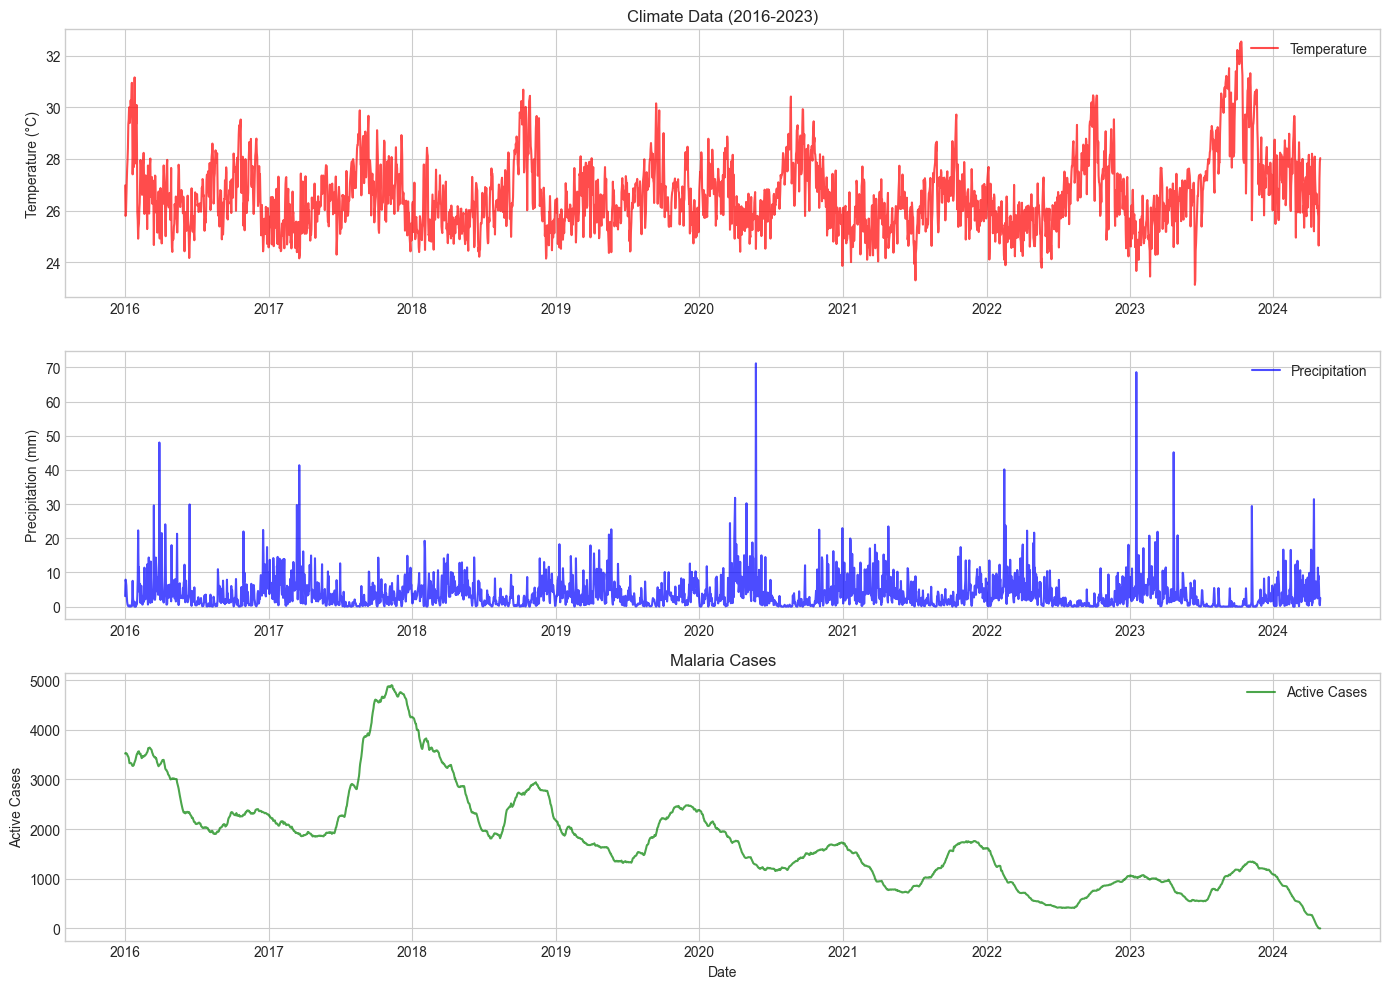

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(merged_df['date'], merged_df['temp_med'], 'r-', alpha=0.7, label='Temperature')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Climate Data (2016-2023)')
axes[0].legend()

axes[1].plot(merged_df['date'], merged_df['precip_med'], 'b-', alpha=0.7, label='Precipitation')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()

axes[2].plot(merged_df['date'], merged_df['active_total'], 'g-', alpha=0.7, label='Active Cases')
axes[2].set_ylabel('Active Cases')
axes[2].set_xlabel('Date')
axes[2].set_title('Malaria Cases')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Prepare Model with Real Climate Data

We need to modify the SIRSEI model to use real climate data instead of sinusoidal approximations. We'll create interpolation functions for temperature and precipitation.

In [5]:
merged_df['day_number'] = (merged_df['date'] - merged_df['date'].min()).dt.days

day_numbers = merged_df['day_number'].values
temperatures = merged_df['temp_med'].values
precipitations = merged_df['precip_med'].values

temp_interp = interp1d(day_numbers, temperatures, kind='linear', 
                       bounds_error=False, fill_value='extrapolate')
precip_interp = interp1d(day_numbers, precipitations, kind='linear',
                          bounds_error=False, fill_value='extrapolate')

print(f"Day range: {day_numbers.min()} to {day_numbers.max()}")
print(f"Temperature range: {temperatures.min():.2f}°C to {temperatures.max():.2f}°C")
print(f"Precipitation range: {precipitations.min():.2f}mm to {precipitations.max():.2f}mm")

Day range: 0 to 3041
Temperature range: 23.12°C to 32.55°C
Precipitation range: 0.00mm to 71.17mm


## 4. Initialize SIRSEIData Model with Real Climate Data

We use the built-in SIRSEIData model which accepts real climate data via interpolation functions, instead of sinusoidal approximations.

In [6]:
model = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)

print("SIRSEIData model initialized with climate data successfully!")
print(f"Model type: {model.model_type}")
print(f"State variables: {list(model.state_variables.keys())}")

SIRSEIData model initialized with climate data successfully!
Model type: SIR-SEI-Data
State variables: ['Sh', 'Ih', 'Rh', 'Sv', 'Ev', 'Iv']


## 5. Prepare Data for Fitting

In [7]:
N = 9586
M = 3000

initial_cases = merged_df['active_total'].iloc[0]
print(f"Initial active cases: {initial_cases}")

initial_recovered = merged_df['active_total'].iloc[0] * 0.1
initial_Ih = initial_cases
initial_Sh = N - initial_Ih - initial_recovered
initial_Sv = M * 0.99
initial_Ev = M * 0.009
initial_Iv = M * 0.001

inits = [initial_Sh, initial_Ih, initial_recovered, initial_Sv, initial_Ev, initial_Iv]
print(f"Initial conditions: Sh={initial_Sh:.0f}, Ih={initial_Ih:.0f}, Rh={initial_recovered:.0f}")
print(f"                   Sv={initial_Sv:.0f}, Ev={initial_Ev:.0f}, Iv={initial_Iv:.0f}")

Initial active cases: 3520
Initial conditions: Sh=5714, Ih=3520, Rh=352
                   Sv=2970, Ev=27, Iv=3


In [8]:
times = merged_df['day_number'].values
observed_cases = merged_df['active_total'].values

print(f"Time points: {len(times)}")
print(f"Time range: {times.min()} to {times.max()} days")
print(f"Cases range: {observed_cases.min()} to {observed_cases.max()}")

Time points: 3042
Time range: 0 to 3041 days
Cases range: 0 to 4897


In [9]:
model_for_dataset = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)

dataset = Dataset(model_for_dataset)
dataset.register(
    name='active_cases',
    values=observed_cases,
    times=times,
    state_variable='Ih',
    time_unit='days',
)

validation = dataset.validate(N + M)
print(f"Dataset valid: {validation.is_valid}")
if not validation.is_valid:
    print(f"Errors: {validation.errors}")

Dataset valid: True


## 6. Define Parameters for Fitting

In [10]:
param_specs = [
    ParameterSpec(name='T_prime', bounds=(15.0, 25.0), initial=21.6),
    ParameterSpec(name='pME', bounds=(0.5, 0.99), initial=0.9),
    ParameterSpec(name='pML', bounds=(0.1, 0.5), initial=0.25),
    ParameterSpec(name='pMP', bounds=(0.5, 0.9), initial=0.75),
    ParameterSpec(name='c1', bounds=(0.01, 0.2), initial=0.0554),
    ParameterSpec(name='c2', bounds=(0.05, 0.5), initial=0.1737),
    ParameterSpec(name='b1', bounds=(0.1, 0.9), initial=0.4),
    ParameterSpec(name='b2', bounds=(0.3, 0.9), initial=0.7),
    ParameterSpec(name='A', bounds=(10.0, 100.0), initial=32.5),
    ParameterSpec(name='B', bounds=(5.0, 30.0), initial=15.0),
    ParameterSpec(name='C', bounds=(20.0, 100.0), initial=48.78),
]

print(f"Optimizable parameters ({len(param_specs)}):")
for spec in param_specs:
    print(f"  {spec.name}: bounds={spec.bounds}, initial={spec.initial}")

Optimizable parameters (11):
  T_prime: bounds=(15.0, 25.0), initial=21.6
  pME: bounds=(0.5, 0.99), initial=0.9
  pML: bounds=(0.1, 0.5), initial=0.25
  pMP: bounds=(0.5, 0.9), initial=0.75
  c1: bounds=(0.01, 0.2), initial=0.0554
  c2: bounds=(0.05, 0.5), initial=0.1737
  b1: bounds=(0.1, 0.9), initial=0.4
  b2: bounds=(0.3, 0.9), initial=0.7
  A: bounds=(10.0, 100.0), initial=32.5
  B: bounds=(5.0, 30.0), initial=15.0
  C: bounds=(20.0, 100.0), initial=48.78


In [11]:
fixed_params = {
    'BE': 200,
    'tauE': 1,
    'tauP': 1,
    'D1': 32.5,
    'RL': 32.26,
    'mu_H': 0.00004,
    'gamma': 1/120,
    'DD': 105,
    'Tmin': 14.5,
    'N': N,
    'M': M,
}

print(f"Fixed parameters ({len(fixed_params)}):")
for k, v in fixed_params.items():
    print(f"  {k}: {v}")

Fixed parameters (11):
  BE: 200
  tauE: 1
  tauP: 1
  D1: 32.5
  RL: 32.26
  mu_H: 4e-05
  gamma: 0.008333333333333333
  DD: 105
  Tmin: 14.5
  N: 9586
  M: 3000


## 7. Run Model Fitting

We'll use a two-stage approach:
1. First, fit with a global optimizer (differential_evolution) to find a good starting point
2. Then refine with L-BFGS-B for precise optimization

In [12]:
test_model = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)

test_params = {**fixed_params}
for spec in param_specs:
    test_params[spec.name] = spec.initial

try:
    test_model(
        inits=inits,
        trange=[times.min(), times.max()],
        totpop=N + M,
        params=test_params,
    )
    print("Model test successful!")
    print(f"Final Ih: {test_model.traces['Ih'][-1]:.2f}")
except Exception as e:
    print(f"Model test failed: {e}")

Model test successful!
Final Ih: 52.65


In [13]:
print("Running global optimization (this may take a while)...")

global_optimizer = ScipyOptimizer(
    method='differential_evolution',
    max_iterations=50,
    tolerance=1e-5,
)
model_for_fitting = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)

fitter_global = ModelFitter(
    model=model_for_fitting,
    dataset=dataset,
    parameters_to_fit=param_specs,
    total_population=N + M,
    fixed_params=fixed_params,
    optimizer=global_optimizer,
    loss_fn=SumOfSquaredErrors(),
)

result_global = fitter_global.fit()

print(f"\n=== Global Optimization Results ===")
print(f"Convergence: {result_global.convergence}")
print(f"Evaluations: {result_global.n_evaluations}")
print(f"Final loss: {result_global.best_loss:.2f}")
print("\nFitted parameters:")
for name, value in result_global.best_params.items():
    print(f"  {name}: {value:.6f}")

Running global optimization (this may take a while)...

=== Global Optimization Results ===
Convergence: True
Evaluations: 4113
Final loss: 10936806404.63

Fitted parameters:
  T_prime: 15.051294
  pME: 0.976018
  pML: 0.408561
  pMP: 0.664937
  c1: 0.014536
  c2: 0.367209
  b1: 0.895663
  b2: 0.800797
  A: 99.705713
  B: 25.478749
  C: 94.655685


## 8. Refine with Local Optimization

In [14]:
refined_param_specs = [
    ParameterSpec(name=spec.name, bounds=spec.bounds, initial=result_global.best_params[spec.name])
    for spec in param_specs
]

local_optimizer = ScipyOptimizer(
    method='L-BFGS-B',
    max_iterations=200,
)

model_for_refine = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)

fitter_refined = ModelFitter(
    model=model_for_refine,
    dataset=dataset,
    parameters_to_fit=refined_param_specs,
    total_population=N + M,
    fixed_params=fixed_params,
    optimizer=local_optimizer,
    loss_fn=SumOfSquaredErrors(),
)

result_refined = fitter_refined.fit()

print(f"\n=== Refined Optimization Results ===")
print(f"Convergence: {result_refined.convergence}")
print(f"Evaluations: {result_refined.n_evaluations}")
print(f"Final loss: {result_refined.best_loss:.2f}")
print("\nFitted parameters:")
for name, value in result_refined.best_params.items():
    orig = next(s.initial for s in param_specs if s.name == name)
    print(f"  {name}: {value:.6f} (original: {orig})")


=== Refined Optimization Results ===
Convergence: False
Evaluations: 648
Final loss: 10936814188.26

Fitted parameters:
  T_prime: 15.051296 (original: 21.6)
  pME: 0.976018 (original: 0.9)
  pML: 0.408561 (original: 0.25)
  pMP: 0.664937 (original: 0.75)
  c1: 0.014536 (original: 0.0554)
  c2: 0.367209 (original: 0.1737)
  b1: 0.895663 (original: 0.4)
  b2: 0.800797 (original: 0.7)
  A: 99.705713 (original: 32.5)
  B: 25.478750 (original: 15.0)
  C: 94.655674 (original: 48.78)


## 9. Visualize Results

In [ ]:
# final_params = {**fixed_params, **result_refined.best_params}

# fitted_model = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)
# fitted_model(
#     inits=inits,
#     trange=[times.min(), times.max()],
#     totpop=N + M,
#     params=final_params,
# )

final_params = {**fixed_params, **result_refined.best_params}

fitted_model = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)
fitted_model(
    inits=inits,
    trange=[times.min(), times.max()],
    totpop=N + M,
    params=final_params,
)

fitted_times = fitted_model.traces['time']
fitted_Ih = fitted_model.traces['Ih']

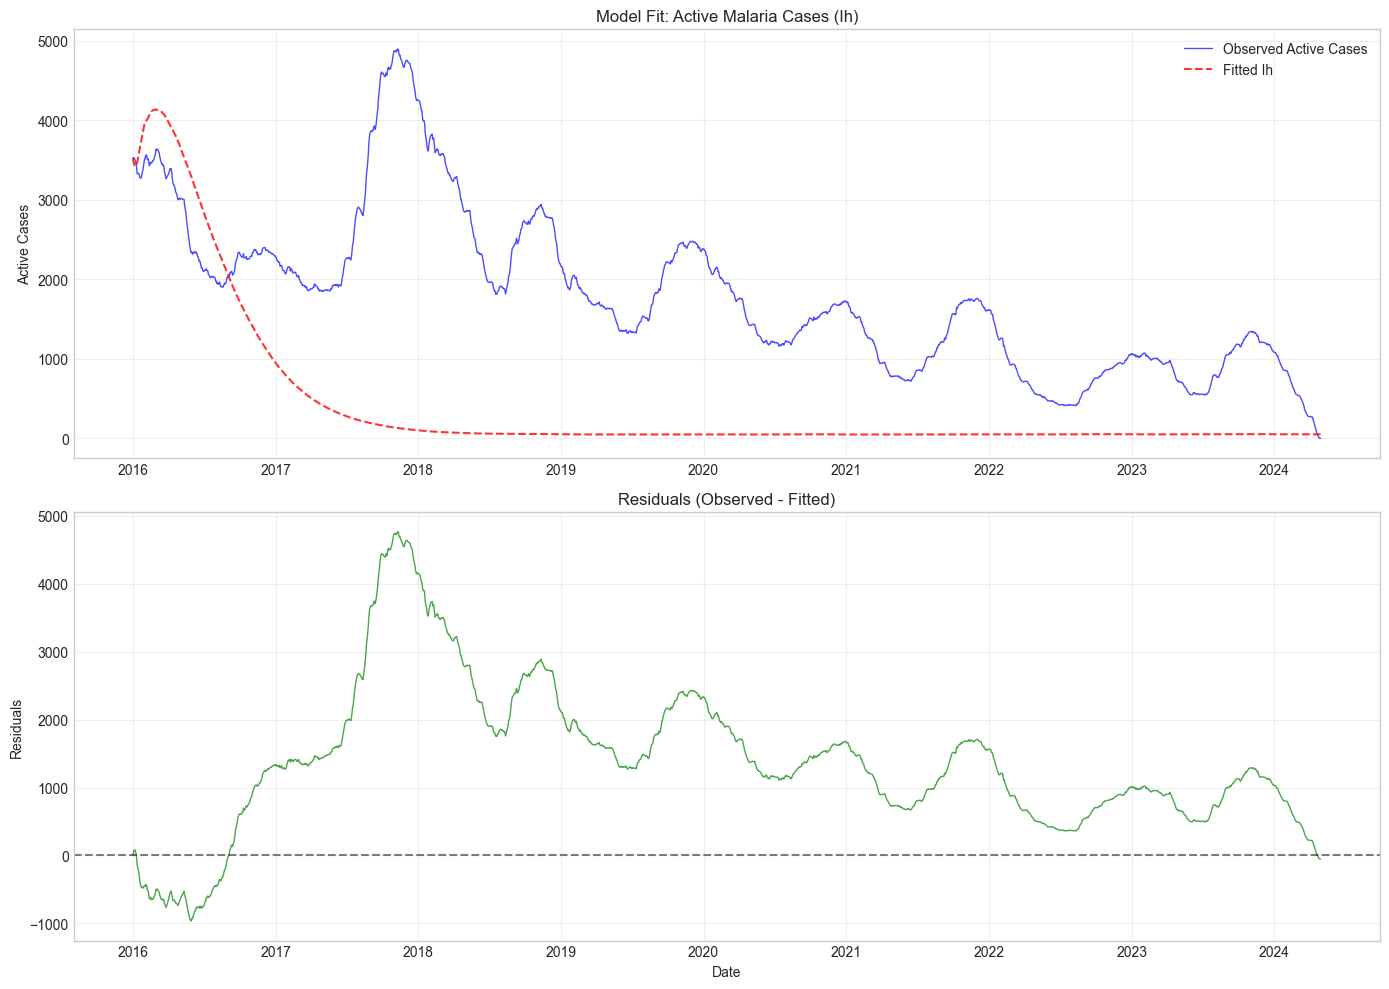


Fit Quality Metrics:
  RMSE: 1768.11
  MAE: 1478.79


In [17]:
dates = merged_df['date'].values

# Interpolate fitted model output to match observed time points
fitted_Ih_interp = np.interp(times, fitted_times, fitted_Ih)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(dates, observed_cases, 'b-', alpha=0.7, linewidth=1, label='Observed Active Cases')
axes[0].plot(dates, fitted_Ih_interp, 'r--', alpha=0.8, linewidth=1.5, label='Fitted Ih')
axes[0].set_ylabel('Active Cases')
axes[0].set_title('Model Fit: Active Malaria Cases (Ih)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = observed_cases - fitted_Ih_interp
axes[1].plot(dates, residuals, 'g-', alpha=0.7, linewidth=1)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Residuals')
axes[1].set_xlabel('Date')
axes[1].set_title('Residuals (Observed - Fitted)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
print(f"\nFit Quality Metrics:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE: {mae:.2f}")

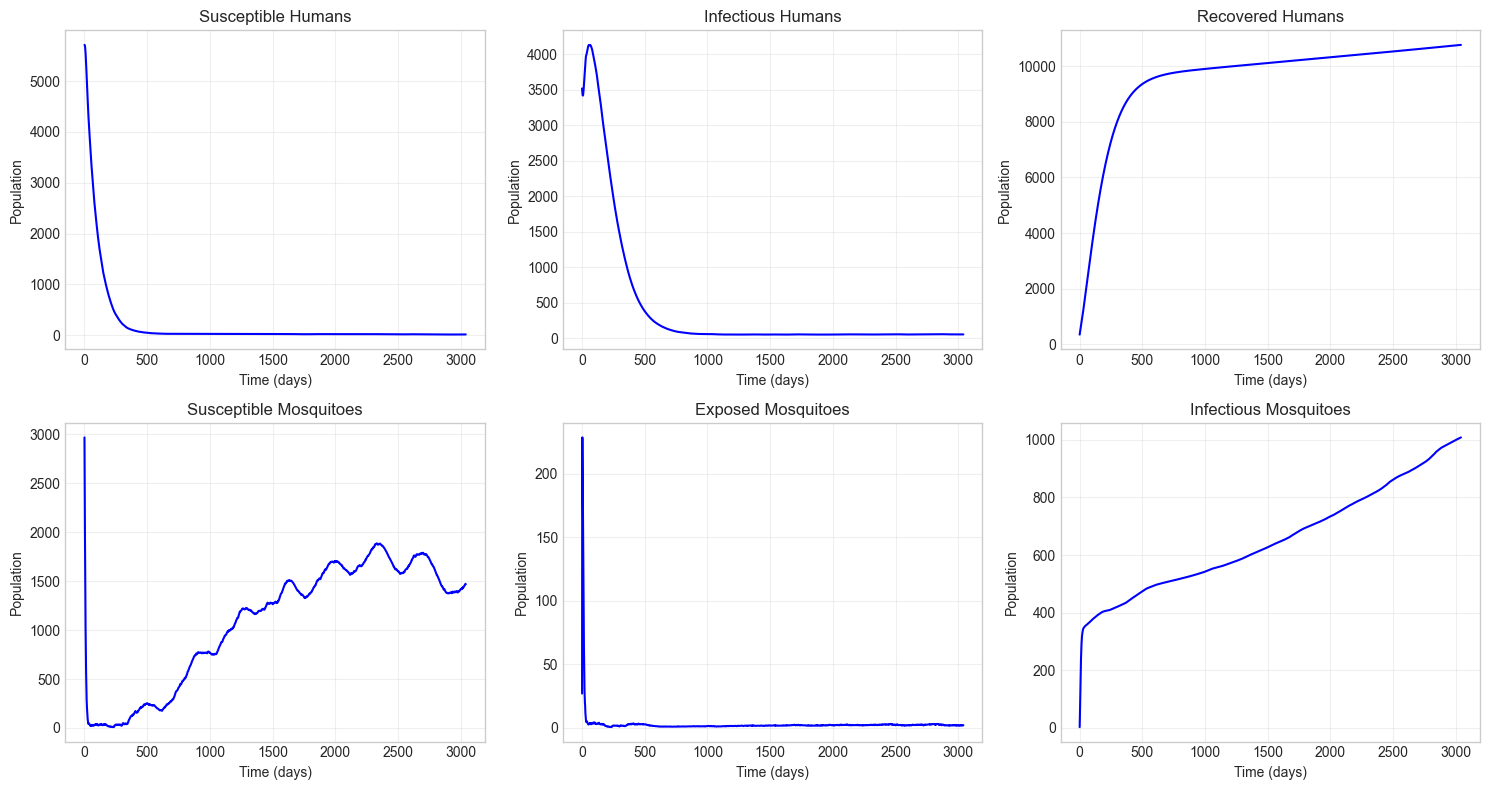

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

compartments = ['Sh', 'Ih', 'Rh', 'Sv', 'Ev', 'Iv']
titles = ['Susceptible Humans', 'Infectious Humans', 'Recovered Humans',
          'Susceptible Mosquitoes', 'Exposed Mosquitoes', 'Infectious Mosquitoes']

for i, (comp, title) in enumerate(zip(compartments, titles)):
    ax = axes[i // 3, i % 3]
    ax.plot(fitted_times, fitted_model.traces[comp], 'b-', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Population')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Save Results

In [19]:
results_df = pd.DataFrame({
    'parameter': list(result_refined.best_params.keys()),
    'fitted_value': list(result_refined.best_params.values()),
    'original_value': [next(s.initial for s in param_specs if s.name == n) for n in result_refined.best_params.keys()],
    'lower_bound': [next(s.bounds[0] for s in param_specs if s.name == n) for n in result_refined.best_params.keys()],
    'upper_bound': [next(s.bounds[1] for s in param_specs if s.name == n) for n in result_refined.best_params.keys()],
})

results_df['change_pct'] = ((results_df['fitted_value'] - results_df['original_value']) / 
                            results_df['original_value'] * 100)

print("Fitted Parameters Summary:")
print(results_df.to_string(index=False))

results_df.to_csv('./sirsei_fitted_parameters.csv', index=False)
print("\nParameters saved to 'sirsei_fitted_parameters.csv'")

Fitted Parameters Summary:
parameter  fitted_value  original_value  lower_bound  upper_bound  change_pct
  T_prime     15.051296         21.6000        15.00        25.00  -30.318074
      pME      0.976018          0.9000         0.50         0.99    8.446433
      pML      0.408561          0.2500         0.10         0.50   63.424236
      pMP      0.664937          0.7500         0.50         0.90  -11.341792
       c1      0.014536          0.0554         0.01         0.20  -73.761949
       c2      0.367209          0.1737         0.05         0.50  111.404283
       b1      0.895663          0.4000         0.10         0.90  123.915756
       b2      0.800797          0.7000         0.30         0.90   14.399566
        A     99.705713         32.5000        10.00       100.00  206.786809
        B     25.478750         15.0000         5.00        30.00   69.858335
        C     94.655674         48.7800        20.00       100.00   94.046072

Parameters saved to 'sirsei_fitted_p

In [20]:
output_df = pd.DataFrame({
    'time': fitted_times,
})

for comp in compartments:
    output_df[comp] = fitted_model.traces[comp]

output_df.to_csv('./sirsei_model_output.csv', index=False)
print(f"Model output saved to 'sirsei_model_output.csv' ({len(output_df)} time points)")

Model output saved to 'sirsei_model_output.csv' (1894 time points)


## 11. Summary and Conclusions

This notebook demonstrated fitting the SIRSEI malaria model to real epidemiological data from Manaus.

### Key Steps:
1. Loaded and merged climate and case data
2. Created interpolation functions for temperature and precipitation
3. Extended the SIRSEI model to use real climate data
4. Defined optimizable and fixed parameters
5. Used a two-stage optimization approach:
   - Global optimization (differential_evolution) for robust starting point
   - Local optimization (L-BFGS-B) for precise refinement
6. Visualized results and computed fit quality metrics

### Notes:
- The fit quality depends on the initial conditions and parameter bounds
- Adjusting bounds may improve fit for specific parameters
- Consider using different loss functions (Poisson, Negative Binomial) for count data
- Profile likelihood can be used to estimate confidence intervals for parameters